In [36]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from scipy.io import loadmat


In [3]:
data = np.load("../final project/preprocessed_data/sub-01/preprocessed_eeg_training.npz")
print(data.files)

['preprocessed_eeg_data', 'ch_names', 'times']


In [9]:
eeg = data["preprocessed_eeg_data"]
fs = 100

In [14]:
eeg.shape

(16540, 4, 17, 500)

In [17]:
data['ch_names'].tolist()

['Pz',
 'P3',
 'P7',
 'O1',
 'Oz',
 'O2',
 'P4',
 'P8',
 'P1',
 'P5',
 'PO7',
 'PO3',
 'POz',
 'PO4',
 'PO8',
 'P6',
 'P2']

### Remove offset

In [15]:
eeg = eeg - eeg.mean(axis=-1, keepdims=True)

In [33]:
eeg_epoch = eeg[0, 0]
eeg_epoch.shape

(17, 500)

In [34]:
eeg_epoch = eeg[0, 1]

info = mne.create_info(ch_names=data['ch_names'].tolist(), sfreq=fs, ch_types='eeg')
raw = mne.io.RawArray(eeg_epoch, info)

Creating RawArray with float64 data, n_channels=17, n_times=500
    Range : 0 ... 499 =      0.000 ...     4.990 secs
Ready.


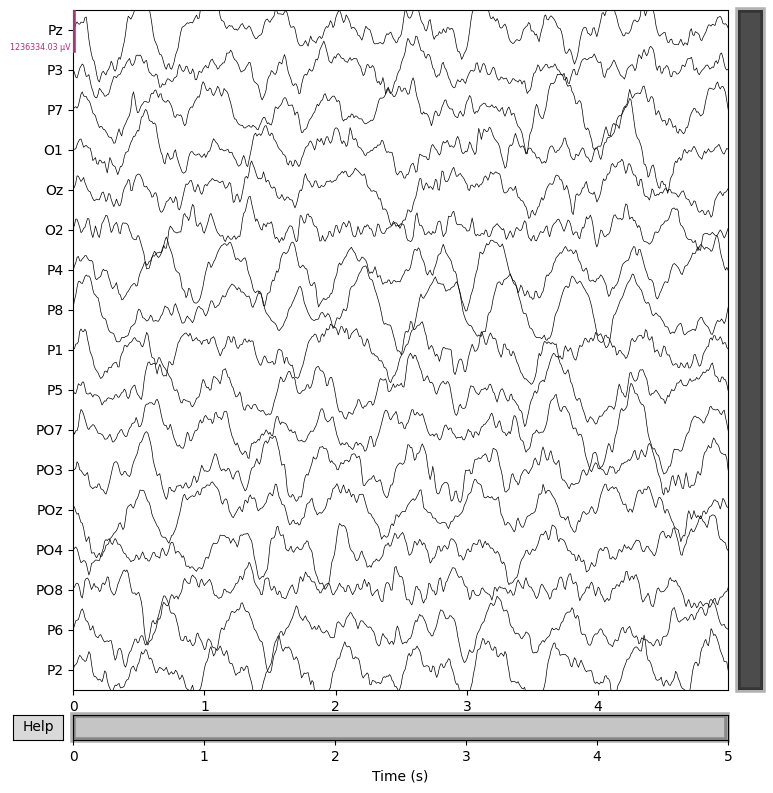

In [51]:
# Time series browser
raw.plot(n_channels=17, scalings='auto');

# # Power spectral density
# raw.plot_psd(fmax=50)

In [40]:
beh = loadmat("../final project/sub-01/ses-01/beh/sub-01_ses-01_task-train_part-01_beh.mat")
print(beh.keys())

# This should be used for aggreation of data, for sub-01 there's 16540 unique images shown
# and each image is shown for 4 times 
# the first aggregation for spectral power is per each image 
# the second is using the beh files and see if we can map each image to the corresponding category
# then aggreate the spectral power by category 

dict_keys(['__header__', '__version__', '__globals__', 'data'])


### Bandpass Filter

In [44]:
#1 Hz to not get dominated by slow drifts
#40 Hz to focus and away from Nyquist edge
raw.filter(1, 40, fir_design='firwin')

# Save cleaned data
cleaned_data = raw.get_data()
# np.savez("cleaned_eeg_training.npz", eeg=cleaned_data)

print("MNE preprocessing complete.")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 331 samples (3.310 s)

MNE preprocessing complete.


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


In [48]:
clean_obj = mne.io.RawArray(cleaned_data, info)

Creating RawArray with float64 data, n_channels=17, n_times=500
    Range : 0 ... 499 =      0.000 ...     4.990 secs
Ready.


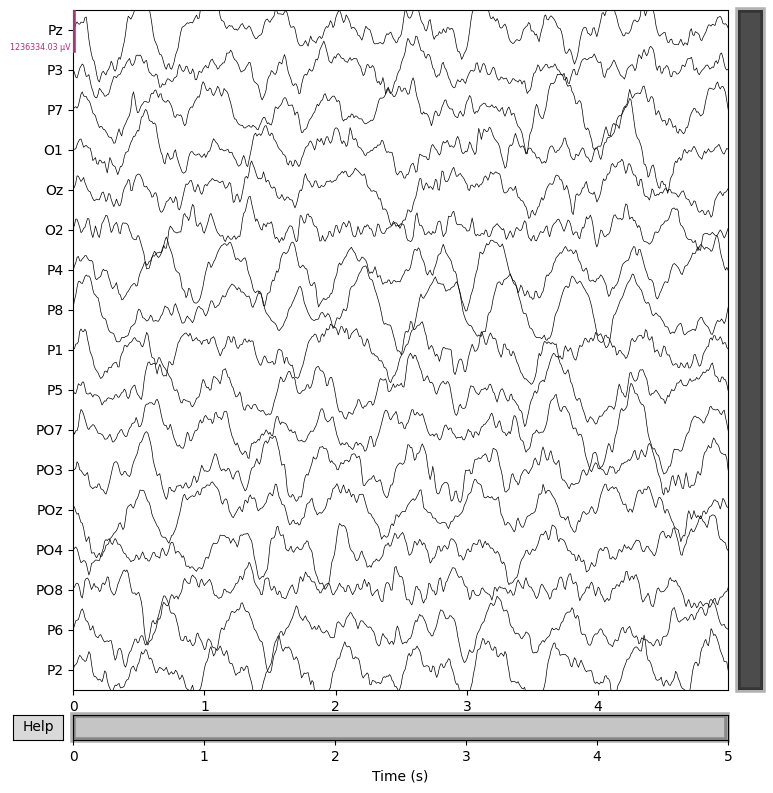

In [50]:
clean_obj.plot(n_channels=17, scalings='auto');

# TODO:

create spectrogram using this single sample and plot graphs